In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df_open_cheminformatics = pd.read_csv("CRBN_database_include_covalency.csv")
df_open_cheminformatics['source'] = 'open_&_cheminformatic_docking'
df_open_cheminformatics

,smiles,cov_crbn_label,source
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0,open_&_cheminformatic_docking
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0,open_&_cheminformatic_docking
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking
...,...,...,...
6582,O=C1CCC(c2cccc(NC(=O)C3Cc4cc(S(=O)(=O)F)ccc4N3...,1,open_&_cheminformatic_docking
6583,O=C1CCC(c2cccc(NC(=O)C3Cc4cccc(S(=O)(=O)F)c4N3...,1,open_&_cheminformatic_docking
6584,O=C1CCC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)C...,1,open_&_cheminformatic_docking
6585,O=C1CCC(N2C(=O)c3ncc(OS(=O)(=O)F)nc3C2=O)C(=O)N1,1,open_&_cheminformatic_docking


In [24]:
def refine_dataset(df):
    # Filter rows where both models agree (both 1 or both 0)
    consensus_mask = df['xgb_pred_label'] == df['gin_pred_label']
    df_refined = df[consensus_mask].copy()
    
    # Assign the consensus label
    df_refined['cov_crbn_label'] = df_refined['xgb_pred_label']
    
    # Reset index to match the structure of a concatenated new dataframe
    return df_refined.reset_index(drop=True)

In [25]:
df_smilesrnn = pd.read_csv("test_with_covalency/smilesrnn_test/cleaned_fresh_imide_molecules_QED_above_05_with_both_predictions.csv")
df_smilesrnn_refined = refine_dataset(df_smilesrnn)
df_smilesrnn_refined.rename(columns={'SMILES': 'smiles'}, inplace=True)
df_smilesrnn_refined

,smiles,xgb_pred_label,source,gin_pred_label,cov_crbn_label
0,O=C1CCN(c2cc(C3CC3)ccc2-c2cccnc2)C(=O)N1,0,smilesrnn_approach_1,0,0
1,Cc1ccncc1-c1ccc(N2CCC(=O)NC2=O)cc1C1CC1,0,smilesrnn_approach_1,0,0
2,CC(C1CC1)n1cc(-c2cccc(N3CCC(=O)NC3=O)c2)cn1,0,smilesrnn_approach_1,0,0
3,COc1cc(-n2ccc(N3CCC(=O)NC3=O)c2C)cc(F)c1F,0,smilesrnn_approach_1,0,0
4,CCn1cc(-c2ccc(N3CCC(=O)NC3=O)cc2)cn1,0,smilesrnn_approach_1,0,0
...,...,...,...,...,...
9129,O=C1CCC(N2Cc3ccc(NC(=O)C4CCc5c4cccc5S(=O)(=O)F...,1,smilesrnn_approach_2,1,1
9130,O=C1CCC(N2Cc3ccc(NC(=O)C4CCc5c4cccc5S(=O)(=O)F...,1,smilesrnn_approach_2,1,1
9131,O=C1CCC(Nc2cccc(NC(=O)c3ncc4[nH]ncc4n3)c2)C(=O)N1,0,smilesrnn_approach_2,0,0
9132,COc1ccc(NC(=O)NC(C)c2ccc3nnn(C4CCC(=O)NC4=O)c(...,0,smilesrnn_approach_2,0,0


In [26]:
df_reinvent4 = pd.read_csv("test_with_covalency/reinvent4_test/cleaned_fresh_imide_molecules_QED_above_05_with_both_predictions.csv")
df_reinvent4_refined = refine_dataset(df_reinvent4)
df_reinvent4_refined.rename(columns={'SMILES': 'smiles'}, inplace=True)
df_reinvent4_refined

,smiles,xgb_pred_label,source,gin_pred_label,cov_crbn_label
0,CN(C)c1cccc(-c2ccc(N3CCC(=O)NC3=O)cc2)c1,0,reinvent4_step15agent,0,0
1,COc1c(-c2cccs2)cccc1N1CCC(=O)NC1=O,0,reinvent4_step15agent,0,0
2,COc1cccc(-c2cccc(N3CCC(=O)NC3=O)c2)c1,0,reinvent4_step15agent,0,0
3,COc1ccc(-c2ccc(N3CCC(=O)NC3=O)cc2)cc1,0,reinvent4_step15agent,0,0
4,O=C1CCN(c2cc(F)ccc2Cc2cccc(F)c2)C(=O)N1,0,reinvent4_step15agent,0,0
...,...,...,...,...,...
5738,O=C1CC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)CC...,1,reinvent4_step50agent,1,1
5739,O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc(S(=O)(=O)F)c...,1,reinvent4_step50agent,1,1
5740,CC(=O)NC(Cc1ccc(Cl)cc1)C(=O)NCc1ccc2c(c1)CN(C1...,0,reinvent4_step50agent,0,0
5741,COC1CCC(=O)NC1=O,0,reinvent4_step50agent,0,0


In [27]:
#concatenate the three refined dataframes by common column 
df_concatenated = pd.concat([df_open_cheminformatics, df_smilesrnn_refined, df_reinvent4_refined], ignore_index=True, join='inner')
df_concatenated

,smiles,cov_crbn_label,source
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0,open_&_cheminformatic_docking
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0,open_&_cheminformatic_docking
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking
...,...,...,...
21459,O=C1CC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)CC...,1,reinvent4_step50agent
21460,O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc(S(=O)(=O)F)c...,1,reinvent4_step50agent
21461,CC(=O)NC(Cc1ccc(Cl)cc1)C(=O)NCc1ccc2c(c1)CN(C1...,0,reinvent4_step50agent
21462,COC1CCC(=O)NC1=O,0,reinvent4_step50agent


In [28]:
from rdkit import Chem
from rdkit.Chem import Descriptors
# Ensure the directory containing esol.py is in the python path if necessary, 
# but since it is in the working directory, import esol should work.
import sys
import os
sys.path.append(os.getcwd())
from esol import ESOLCalculator

esol_calculator = ESOLCalculator()

def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        clogp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        logs = esol_calculator.calc_esol(mol)
        return pd.Series([clogp, tpsa, logs])
    else:
        return pd.Series([None, None, None])

# Calculate properties and assign to new columns
df_concatenated[['clogP', 'TPSA', 'logS']] = df_concatenated['smiles'].apply(calculate_properties)
df_concatenated

,smiles,cov_crbn_label,source,clogP,TPSA,logS
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking,0.1458,103.78,-1.868319
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking,0.1458,103.78,-1.868319
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0,open_&_cheminformatic_docking,-0.1928,95.58,-1.697918
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0,open_&_cheminformatic_docking,0.1973,95.58,-2.071512
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0,open_&_cheminformatic_docking,0.3398,95.58,-2.252007
...,...,...,...,...,...,...
21459,O=C1CC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)CC...,1,reinvent4_step50agent,1.6513,122.53,-3.846065
21460,O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc(S(=O)(=O)F)c...,1,reinvent4_step50agent,-0.5958,151.83,-2.174595
21461,CC(=O)NC(Cc1ccc(Cl)cc1)C(=O)NCc1ccc2c(c1)CN(C1...,0,reinvent4_step50agent,1.4646,124.68,-4.233803
21462,COC1CCC(=O)NC1=O,0,reinvent4_step50agent,-0.5620,55.40,-0.265242


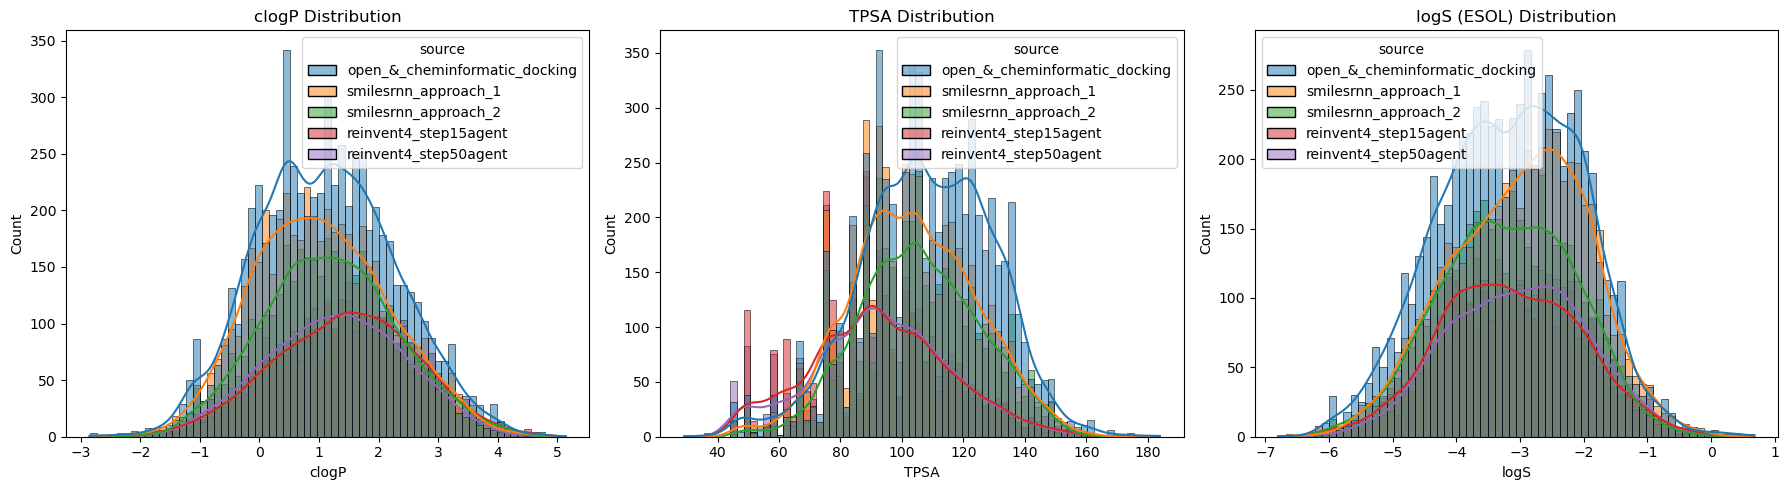

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot clogP distribution
sns.histplot(data=df_concatenated, x="clogP", hue="source", kde=True, ax=axes[0])
axes[0].set_title('clogP Distribution')

# Plot TPSA distribution
sns.histplot(data=df_concatenated, x="TPSA", hue="source", kde=True, ax=axes[1])
axes[1].set_title('TPSA Distribution')
# Plot logS distribution
sns.histplot(data=df_concatenated, x="logS", hue="source", kde=True, ax=axes[2])
axes[2].set_title('logS (ESOL) Distribution')

plt.tight_layout()
plt.show()

In [35]:
from rdkit.Chem import QED
import mols2grid

# Filter dataframe based on criteria
df_selected = df_concatenated[
    (df_concatenated['clogP'] >= 1.0) & (df_concatenated['clogP'] <= 3.5) &
    (df_concatenated['TPSA'] < 130) &
    (df_concatenated['logS'] > -4)
].copy()

# Calculate QED score
def calculate_qed(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return QED.qed(mol)
    return None

df_selected['QED'] = df_selected['smiles'].apply(calculate_qed)

# Sort by QED (> 0.67), select covalent CRBN binders (cov_crbn_label == 1) and drop source with open_&_cheminformatic_docking
df_selected_sorted = df_selected[df_selected['QED'] > 0.67].sort_values(by='QED', ascending=False)
df_selected_sorted = df_selected_sorted[df_selected_sorted['cov_crbn_label'] == 1]
df_selected_sorted = df_selected_sorted[df_selected_sorted['source'] != 'open_&_cheminformatic_docking']

# Round numerical values to 3 decimal places
float_cols = ['clogP', 'TPSA', 'logS', 'QED']
df_selected_sorted[float_cols] = df_selected_sorted[float_cols].round(3)

# Display using mols2grid with labeled properties
mols2grid.display(df_selected_sorted, 
                  smiles_col="smiles", 
                  subset=["source", "clogP", "TPSA", "logS", "QED"],
                  tooltip=["source", "clogP", "TPSA", "logS", "QED"],
                  transform={col: lambda x, c=col: f"{c}: {x}" for col in ["source", "clogP", "TPSA", "logS", "QED"]})